# **Evaluation Notebook**

### **Wikiart Project**

**Group x:**\
**Afonso Hermenegildo** - 202 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951 | **André Nicolau** - 2022

Github repository: https://github.com/MarcoAFMartins/Wikiart_Project

---

# Table of Contents

1. [Classification report (accuracy, macro-F1, per-class precision/recall)](#section-1)  
2. [Confusion matrix (seaborn heatmap)](#section-2)  
3. [Training curves (loss & accuracy)](#section-3)  
4. [Grad-CAM visualisation](#section-4)  
5. [Misclassified samples analysis](#section-5)
6. [Model comparison table](#section-5)

---

# Imports

In [10]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import image_dataset_from_directory
from notebooks.baseline_model import BaselineModel

# Paths — adjust if needed
DATA_DIR    = Path('Data')
OUTPUTS_DIR = Path('outputs')
FIGURES_DIR = OUTPUTS_DIR / 'figures'
MODULES_DIR  = OUTPUTS_DIR / 'modules'
NOTEBOOK_DIR = Path('notebooks')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE  = 32
SEED        = 42

# Load dataset

In [4]:
train_df = image_dataset_from_directory(
    DATA_DIR / "Train",
    label_mode="categorical",
    image_size=(128, 128),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_df = image_dataset_from_directory(
    DATA_DIR / "Validation",
    label_mode="categorical",
    image_size=(128, 128),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

test_df = image_dataset_from_directory(
    DATA_DIR / "Test",
    label_mode="categorical",
    image_size=(128, 128),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

class_names = train_df.class_names
print(f"Classes: {len(class_names)} — {class_names}")

Found 9338 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Classes: 23 — ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


Because we've done our one subclassed model, model.build() often fails to statically infer shapes through complex internal layers like data augmentation. 
By running a dummy image through the network instead, we force a real forward pass that guarantees every layer dynamically initializes its weights based on the actual tensor size.

In [16]:
# Load the best checkpoint saved during training
# Update the path to match whichever model you want to evaluate
model = BaselineModel()
model.build((None, 128, 128, 3))

# 2. Create a "dummy" image (Batch size 1, 128x128 pixels, 3 color channels)
# We fill it with zeros so it processes instantly
dummy_image = tf.zeros((1, 128, 128, 3))

# 3. FORCE the model to build by doing a quick prediction
# We don't care about the output, we just need the data to flow through
_ = model(dummy_image)

model_path = MODULES_DIR / "baseline_cnn.keras/model.weights.h5"
model.load_weights(model_path)

print(f'Model loaded from: {model_path}')
model.summary()

c:\Users\marco\anaconda3\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'baseline_model_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model loaded from: outputs\modules\baseline_cnn.keras\model.weights.h5


Model: "baseline_model_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_moderate_noise     │ ?                      │   0 (unbuilt) │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (1, 128, 128, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (1, 126, 126, 128)     │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (1, 124, 124, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (1, 60, 60, 256)       │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (1, 58, 58, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (1, 27, 27, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (1, 25, 25, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (1, 10, 10, 512)       │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (1, 8, 8, 512)         │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1, 23)                │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,768,343 (22.00 MB)

 Trainable params: 5,768,343 (22.00 MB)

 Non-trainable params: 0 (0.00 B)

# Make Predictions

In [17]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_df:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

accuracy = np.mean(y_true == y_pred)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.4768


# Classification Report

## 4. Classification report
> Primary metric for this project is **macro-F1** because classes may be imbalanced.
> Macro-F1 gives equal weight to all classes regardless of size.
> If macro-F1 is much lower than accuracy, the model is biased toward majority classes.

In [20]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save as file for the report
with open(OUTPUTS_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)
print('Saved!')

                       precision    recall  f1-score   support

       Albrecht_Durer       0.58      0.64      0.61        87
      Boris_Kustodiev       0.31      0.23      0.26        66
     Camille_Pissarro       0.30      0.38      0.33        93
        Childe_Hassam       0.26      0.09      0.13        58
         Claude_Monet       0.37      0.58      0.45       140
          Edgar_Degas       0.31      0.22      0.26        64
        Eugene_Boudin       0.69      0.41      0.52        58
         Gustave_Dore       0.69      0.91      0.78        79
           Ilya_Repin       0.50      0.26      0.34        57
      Ivan_Aivazovsky       0.64      0.78      0.70        60
        Ivan_Shishkin       0.61      0.49      0.55        55
  John_Singer_Sargent       0.56      0.48      0.52        83
         Marc_Chagall       0.44      0.30      0.35        81
      Martiros_Saryan       0.30      0.32      0.31        60
     Nicholas_Roerich       0.57      0.67      0.62  

## 5. Confusion matrix
> The diagonal = correct predictions. Off-diagonal = errors.
> Look for clusters of errors between visually similar classes.

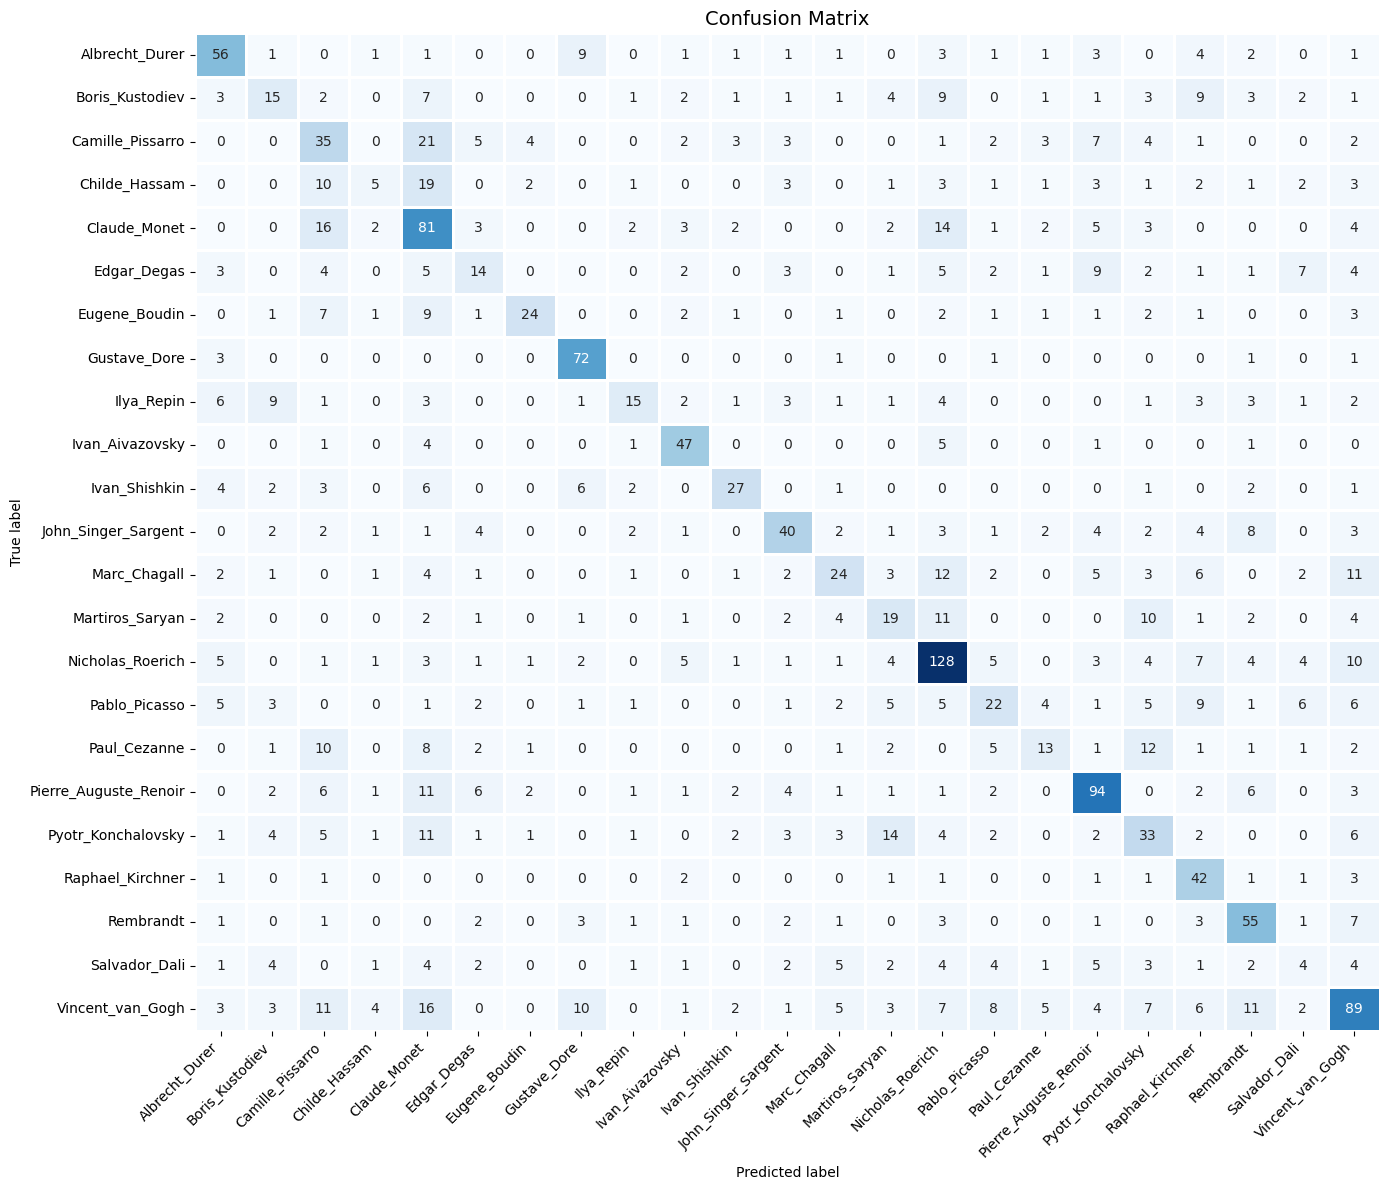


Per-class accuracy:
  Albrecht_Durer                 0.644
  Boris_Kustodiev                0.227
  Camille_Pissarro               0.376
  Childe_Hassam                  0.086
  Claude_Monet                   0.579
  Edgar_Degas                    0.219
  Eugene_Boudin                  0.414
  Gustave_Dore                   0.911
  Ilya_Repin                     0.263
  Ivan_Aivazovsky                0.783
  Ivan_Shishkin                  0.491
  John_Singer_Sargent            0.482
  Marc_Chagall                   0.296
  Martiros_Saryan                0.317
  Nicholas_Roerich               0.670
  Pablo_Picasso                  0.275
  Paul_Cezanne                   0.213
  Pierre_Auguste_Renoir          0.644
  Pyotr_Konchalovsky             0.344
  Raphael_Kirchner               0.764
  Rembrandt                      0.671
  Salvador_Dali                  0.078
  Vincent_van_Gogh               0.449


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=1,
    cbar=False,
    annot_kws={'fontsize': 10},
    yticklabels=class_names,
    xticklabels=class_names,
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# save figure for the report
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    per_class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f'  {name:<30} {per_class_acc:.3f}')

## 6. Training curves
> Load from the CSVLogger output saved during training.
> **Overfitting signal**: val_loss increases while train_loss decreases.
> **Underfitting signal**: both losses remain high.